**Approach 1:**

In [1]:
#install dependencies
!pip install tensorflow tensorflow_hub librosa matplotlib seaborn scikit-learn soundfile joblib

In [2]:
#import libraries
import os
import numpy as np
import librosa
import librosa.display
import tensorflow as tf
import tensorflow_hub as hub
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras import layers, models
import joblib

2026-03-24 20:43:27.830492: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774385008.041196      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774385008.100020      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774385008.651739      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774385008.651783      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774385008.651786      24 computation_placer.cc:177] computation placer alr

In [3]:
#pre trained audio feature extractor
yamnet_model = hub.load('https://tfhub.dev/google/yamnet/1')

I0000 00:00:1774385038.719509      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774385038.725434      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [4]:
DATASET_PATH = "/kaggle/input/datasets/shagnikguha/gunshot-detection-dataset-custom"

In [5]:
def plot_waveform(file):

    signal, sr = librosa.load(file, sr=16000)

    plt.figure(figsize=(10,4))
    librosa.display.waveshow(signal, sr=sr)

    plt.title("Audio Waveform")
    plt.xlabel("Time")
    plt.ylabel("Amplitude")

    plt.show()

In [6]:
def plot_spectrogram(file):

    signal, sr = librosa.load(file, sr=16000)
    spectrogram = librosa.feature.melspectrogram(y=signal, sr=sr)
    log_spec = librosa.power_to_db(spectrogram)

    plt.figure(figsize=(10,4))

    librosa.display.specshow(log_spec, sr=sr, x_axis='time', y_axis='mel')

    plt.title("Mel Spectrogram")
    plt.colorbar(format="%+2.f dB")
    plt.show()

Class: CombinedAudio


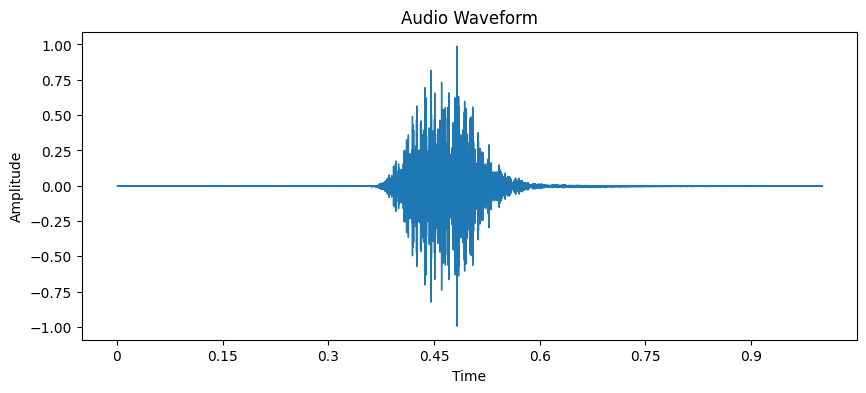

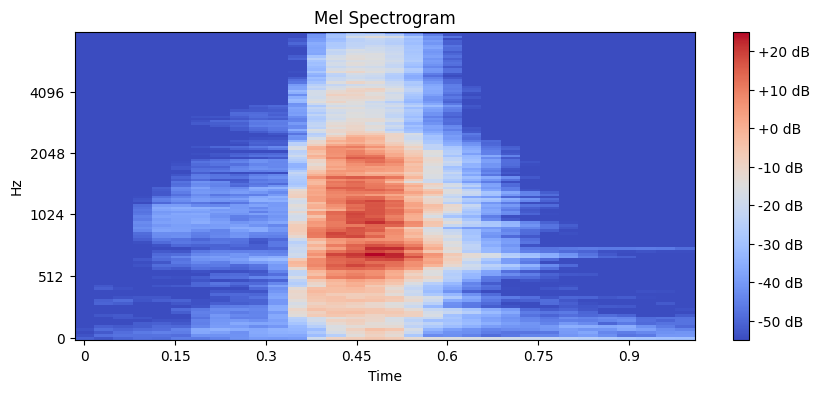

Class: CombinedAudio


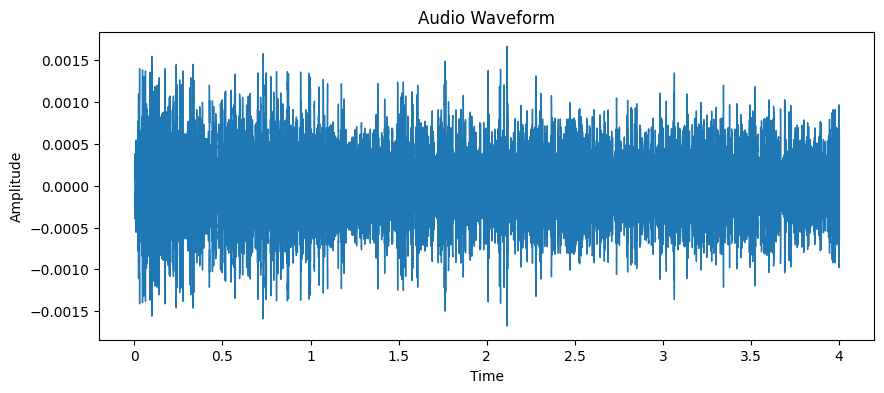

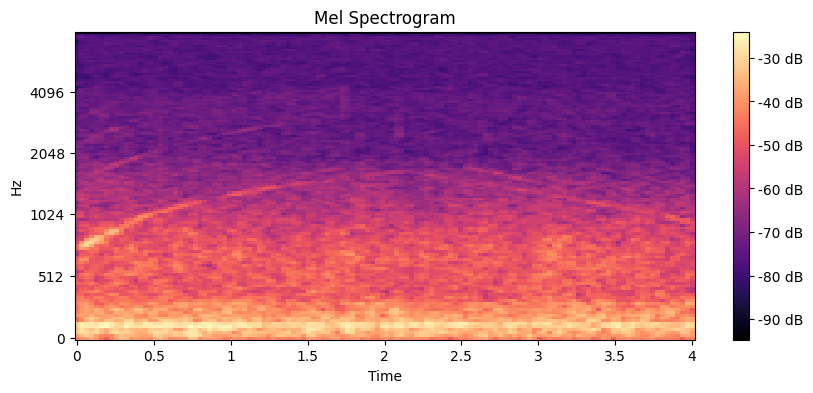

Class: CombinedAudio


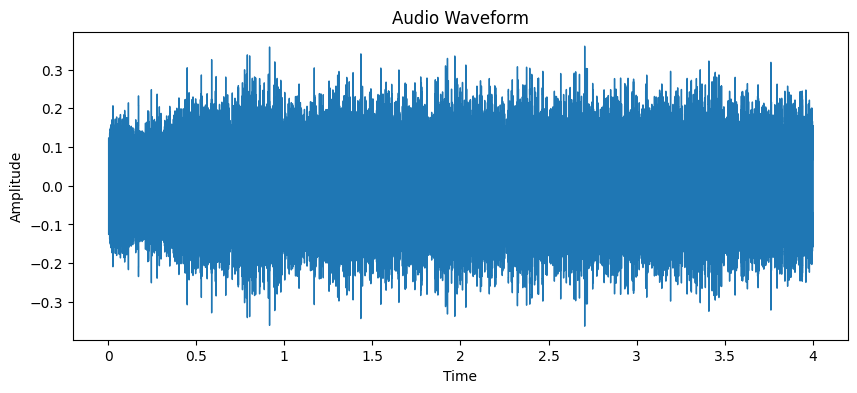

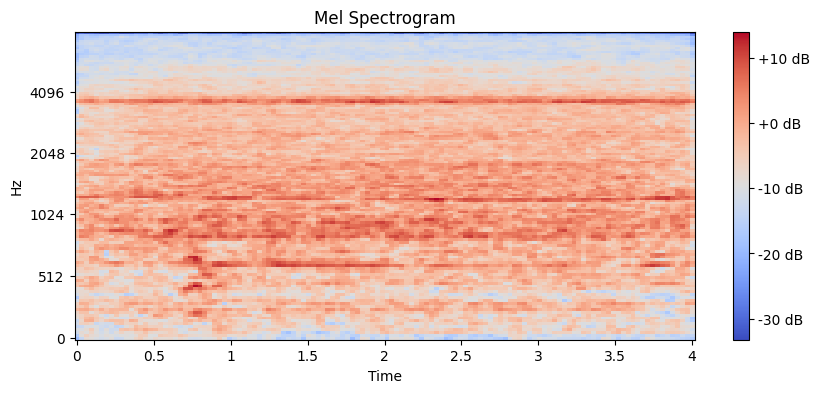

In [7]:
import random

for i in range(3):

    label = random.choice(os.listdir(DATASET_PATH))
    file = random.choice(os.listdir(os.path.join(DATASET_PATH, label)))

    sample = os.path.join(DATASET_PATH, label, file)

    print("Class:", label)

    plot_waveform(sample)
    plot_spectrogram(sample)

In [8]:
#creating labels
def auto_label(file_path):

    signal, sr = librosa.load(file_path, sr=16000)
    peak_energy = np.max(np.abs(signal))

    if peak_energy > 0.6:
        return "gunshot"
    else:
        return "background"

In [9]:
#feature extraction
def extract_embedding(file_path):

    waveform, sr = librosa.load(file_path, sr=16000)
    waveform = waveform.astype(np.float32)

    scores, embeddings, spectrogram = yamnet_model(waveform)
    embedding = tf.reduce_mean(embeddings, axis=0)

    return embedding.numpy()

In [10]:
X = []
y = []

for label in os.listdir(DATASET_PATH):

    label_path = os.path.join(DATASET_PATH, label)

    if not os.path.isdir(label_path):
        continue

    for file in os.listdir(label_path):

        if file.endswith(".wav"):

            path = os.path.join(label_path, file)

            try:
                emb = extract_embedding(path)
                label = auto_label(path)

                X.append(emb)
                y.append(label)

            except:
                pass

X = np.array(X)
y = np.array(y)

print("Dataset Shape:", X.shape)

I0000 00:00:1774385059.054044      75 cuda_dnn.cc:529] Loaded cuDNN version 91002


Dataset Shape: (11731, 1024)


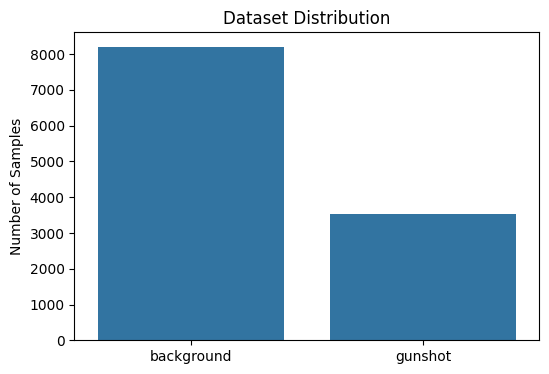

In [11]:
#dataset distribution
unique, counts = np.unique(y, return_counts=True)

plt.figure(figsize=(6,4))
sns.barplot(x=unique, y=counts)

plt.title("Dataset Distribution")
plt.ylabel("Number of Samples")

plt.show()

In [12]:
#encoding labels
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

print("Classes:", encoder.classes_)

Classes: ['background' 'gunshot']


In [13]:
#train test split
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

In [14]:
#model building
model = models.Sequential([
    layers.Dense(256, activation='relu', input_shape=(X.shape[1],)),
    layers.Dropout(0.3),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(64, activation='relu'),

    layers.Dense(len(np.unique(y_encoded)), activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 303,682 (1.16 MB)

 Trainable params: 303,682 (1.16 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
history = model.fit(

    X_train,
    y_train,

    epochs=30,
    batch_size=32,

    validation_data=(X_test, y_test)
)

Epoch 1/30


I0000 00:00:1774385491.540577      73 service.cc:152] XLA service 0x7a55f80431b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774385491.540627      73 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1774385491.540632      73 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5


 74/294 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7758 - loss: 0.4919

I0000 00:00:1774385493.568414      73 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


294/294 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.8094 - loss: 0.4490 - val_accuracy: 0.8543 - val_loss: 0.3629
Epoch 2/30
294/294 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8621 - loss: 0.3370 - val_accuracy: 0.8628 - val_loss: 0.3121
Epoch 3/30
294/294 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8671 - loss: 0.3144 - val_accuracy: 0.8794 - val_loss: 0.3024
Epoch 4/30
294/294 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8824 - loss: 0.2932 - val_accuracy: 0.8573 - val_loss: 0.3151
Epoch 5/30
294/294 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9011 - loss: 0.2589 - val_accuracy: 0.8833 - val_loss: 0.2604
Epoch 6/30
294/294 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9016 - loss: 0.2462 - val_accuracy: 0.8803 - val_loss: 0.2639
Epoch 7/30
294/294 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9017 - loss: 0.2449 - val_accuracy: 0.8892 - val_loss: 0.2563
Epoch 8/30
294/294 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9053 - loss: 0.2289 - val_accuracy: 0.8845 - val

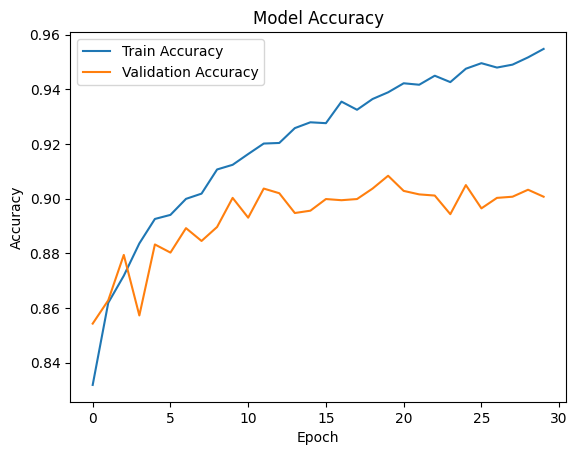

In [16]:
#training performance
plt.figure()

plt.plot(history.history['accuracy'], label="Train Accuracy")
plt.plot(history.history['val_accuracy'], label="Validation Accuracy")

plt.title("Model Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.show()

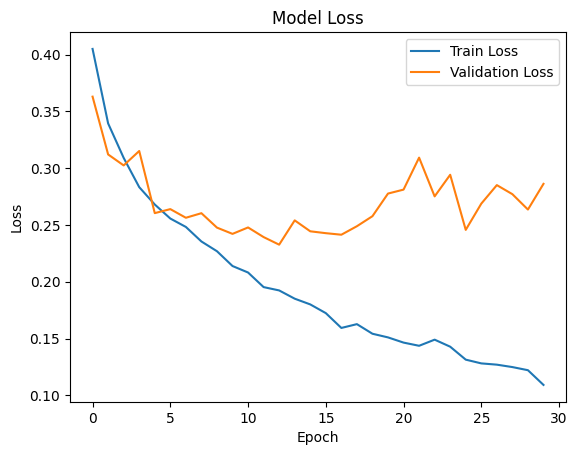

In [17]:
plt.figure()

plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")

plt.title("Model Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.show()

In [18]:
#model evaluation
pred = model.predict(X_test)

pred_labels = np.argmax(pred, axis=1)

print(classification_report(y_test, pred_labels))

74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
              precision    recall  f1-score   support

           0       0.91      0.96      0.93      1632
           1       0.89      0.77      0.83       715

    accuracy                           0.90      2347
   macro avg       0.90      0.86      0.88      2347
weighted avg       0.90      0.90      0.90      2347



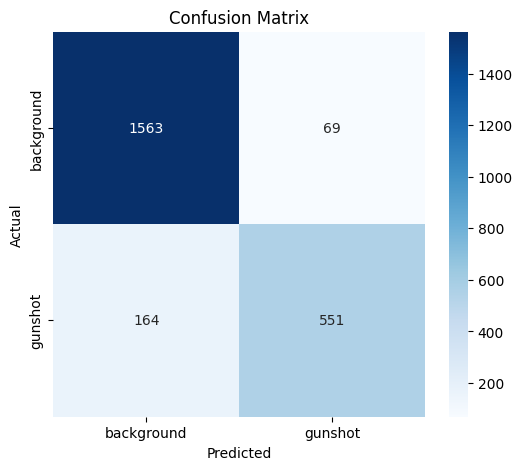

In [19]:
cm = confusion_matrix(y_test, pred_labels)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=encoder.classes_,
            yticklabels=encoder.classes_)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [20]:
#saving the model
model.save("gunshot_detection_model.h5")

joblib.dump(encoder, "label_encoder.pkl")

print("Model Saved Successfully")

Model Saved Successfully


**Approach 2: Sliding Window**

In [21]:
import os
import numpy as np
import pandas as pd
import librosa
import tensorflow as tf
import tensorflow_hub as hub
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras import layers, models
import joblib

In [22]:
DATASET_PATH = "/kaggle/input/datasets/shagnikguha/gunshot-detection-dataset-custom/CombinedAudio"
CSV_PATH = "/kaggle/input/datasets/shagnikguha/gunshot-detection-dataset-custom/CombinedAudio/labels.csv"

In [23]:
labels_df = pd.read_csv(CSV_PATH)

labels_df.head()

,file_name,label
0,22601-8-0-24.wav,0
1,144068-5-0-9.wav,0
2,159761-0-0-6.wav,0
3,18594-1-4-0.wav,0
4,103199-4-2-4.wav,0


In [24]:
#setting parameters
SAMPLE_RATE = 16000
WINDOW_SIZE = 1.0      # seconds
STEP_SIZE = 0.5        # seconds

In [25]:
yamnet_model = hub.load("https://tfhub.dev/google/yamnet/1")

In [26]:
def extract_embeddings_sliding(file_path):

    signal, sr = librosa.load(file_path, sr=SAMPLE_RATE)

    window_length = int(WINDOW_SIZE * SAMPLE_RATE)
    step = int(STEP_SIZE * SAMPLE_RATE)

    embeddings_list = []

    for start in range(0, len(signal) - window_length, step):

        window = signal[start:start + window_length]
        window = window.astype(np.float32)
        scores, embeddings, spectrogram = yamnet_model(window)
        emb = tf.reduce_mean(embeddings, axis=0)
        embeddings_list.append(emb.numpy())

    return embeddings_list

In [27]:
X = []
y = []

for _, row in labels_df.iterrows():

    file_name = row["file_name"]
    label = row["label"]

    file_path = os.path.join(DATASET_PATH, file_name)

    if not os.path.exists(file_path):
        continue

    try:

        embeddings = extract_embeddings_sliding(file_path)

        for emb in embeddings:
            X.append(emb)
            y.append(label)

    except:
        pass


X = np.array(X)
y = np.array(y)

print("Dataset Shape:", X.shape)

Dataset Shape: (65823, 1024)


In [28]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [30]:
model = models.Sequential([

    layers.Dense(512, activation='relu', input_shape=(X.shape[1],)),
    layers.BatchNormalization(),
    layers.Dropout(0.4),

    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),

    layers.Dense(2, activation='softmax')

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [31]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 692,354 (2.64 MB)

 Trainable params: 690,818 (2.64 MB)

 Non-trainable params: 1,536 (6.00 KB)

In [32]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [33]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

Epoch 1/50
1646/1646 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.9271 - loss: 0.1981 - val_accuracy: 0.9646 - val_loss: 0.1005
Epoch 2/50
1646/1646 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9601 - loss: 0.1141 - val_accuracy: 0.9733 - val_loss: 0.0751
Epoch 3/50
1646/1646 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9658 - loss: 0.0951 - val_accuracy: 0.9768 - val_loss: 0.0673
Epoch 4/50
1646/1646 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9684 - loss: 0.0859 - val_accuracy: 0.9760 - val_loss: 0.0662
Epoch 5/50
1646/1646 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9718 - loss: 0.0800 - val_accuracy: 0.9774 - val_loss: 0.0595
Epoch 6/50
1646/1646 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9741 - loss: 0.0743 - val_accuracy: 0.9803 - val_loss: 0.0572
Epoch 7/50
1646/1646 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9764 - loss: 0.0695 - val_accuracy: 0.9772 - val_loss: 0.0592
Epoch 8/50
1646/1646 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9754 - loss: 0.0679 -

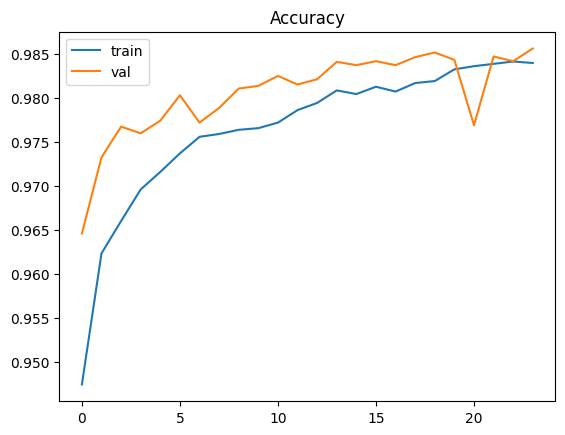

In [34]:
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.title("Accuracy")
plt.show()

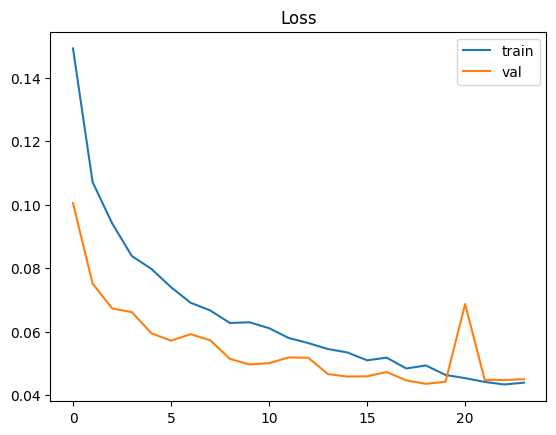

In [35]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend()
plt.title("Loss")
plt.show()

In [36]:
pred = model.predict(X_test)

pred_labels = np.argmax(pred, axis=1)

print(classification_report(y_test, pred_labels))

412/412 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      9285
           1       0.97      0.98      0.97      3880

    accuracy                           0.99     13165
   macro avg       0.98      0.98      0.98     13165
weighted avg       0.99      0.99      0.99     13165



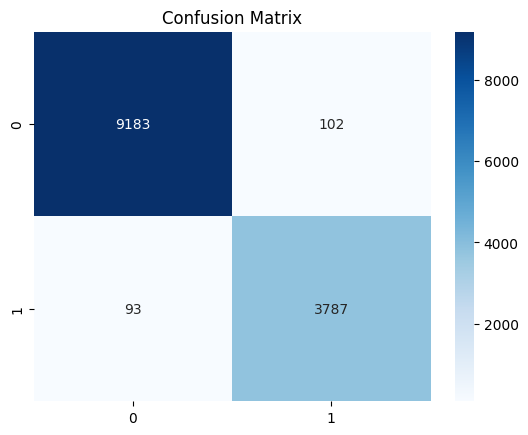

In [37]:
cm = confusion_matrix(y_test, pred_labels)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

In [38]:
model.save("gunshot_detection_model_sliding.h5")

print("Model Saved")

Model Saved
